# House Prices - Advanced Regression Techniques

## Final Exam Project (Retake) – Machine Learning

**Author:** Todor Yankov  
**Course:** Machine Learning  
**Project Type:** Technical Report with Experimental Evaluation  
**Date:** July 2026

---

## Executive Summary

This project investigates the problem of predicting residential house sale prices using the **House Prices – Advanced Regression Techniques** dataset from Kaggle.

The objective is to develop an accurate and interpretable machine learning pipeline capable of estimating house prices based on structural, geographical, and quality-related characteristics of residential properties located in Ames, Iowa.

Rather than focusing solely on achieving a high Kaggle score, this project aims to demonstrate a complete machine learning workflow, including data exploration, mathematical foundations, feature engineering, model development, hyperparameter optimization, ensemble learning, model explainability, and experimental evaluation.

The proposed solution combines several complementary regression models using a Ridge Regression stacking meta-learner. The final model is further combined with an H2O AutoML ensemble, producing a **public Kaggle RMSLE score of 0.11921**, placing the solution among the top-performing submissions.

Throughout this notebook, every modelling decision is justified, experimental improvements are analysed, and the strengths and limitations of the proposed approach are discussed. 

# 1. Introduction

House price prediction is one of the most widely studied regression problems in machine learning. Accurate property valuation is important for buyers, sellers, real estate agencies, banks, insurance companies, and investors, where reliable price estimates support financial and business decisions.

Unlike simple linear prediction tasks, house prices depend on many interacting factors, including property size, construction quality, neighborhood, age of the building, garage capacity, basement characteristics, and many other structural attributes. These relationships are often nonlinear, making the problem particularly suitable for modern machine learning techniques.

This project is based on the **House Prices – Advanced Regression Techniques** Kaggle competition. The dataset contains **79 explanatory variables** describing residential properties in Ames, Iowa. The objective is to predict the final sale price (`SalePrice`) of each house as accurately as possible.

From a machine learning perspective, this is a **supervised regression problem**, where historical observations with known sale prices are used to train predictive models capable of estimating prices for previously unseen houses.

The project follows a complete machine learning workflow, starting with exploratory data analysis and data preprocessing, followed by feature engineering, model development, hyperparameter optimization, ensemble learning, explainable artificial intelligence (XAI), and experimental evaluation. 

# 2. Problem Formulation

The task is to predict the sale price of a house based on a set of explanatory variables describing its physical, qualitative, and location-related characteristics.

Let each house be represented by a feature vector

$$
\mathbf{x}_i =
(x_{i1}, x_{i2}, \ldots, x_{ip})
$$

where:

- $\mathbf{x}_i$ is the feature vector for the $i$-th house,
- $p$ is the number of explanatory variables,
- $y_i$ is the true sale price of the $i$-th house.

The goal is to learn a function

$$
f(\mathbf{x}_i) \approx y_i
$$

that can generalize well to unseen houses from the test dataset.

Since house prices are positive and strongly right-skewed, the target variable is transformed using

$$
z_i = \log(y_i + 1)
$$

The model is trained to predict $z_i$ instead of directly predicting $y_i$. After prediction, the inverse transformation is applied:

$$
\hat{y}_i = \exp(\hat{z}_i) - 1
$$

This transformation is useful because it reduces the influence of very expensive houses and makes the prediction task more consistent with the RMSLE evaluation metric.

Therefore, the machine learning objective is to minimize the prediction error in logarithmic price space while maintaining good generalization on unseen data. 

## 3. Mathematical Background

### RMSLE (Root Mean Squared Log Error)

The competition uses **RMSLE** as the evaluation metric. It is defined as:

\[
\text{RMSLE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( \log(y_i + 1) - \log(\hat{y}_i + 1) \right)^2 }
\]

where:
- \( y_i \) is the actual sale price,
- \( \hat{y}_i \) is the predicted sale price,
- \( \log \) is the natural logarithm (base \( e \)).

**Why RMSLE?**
1.  **Handling Skewness**: It penalizes underestimation more than overestimation, which is suitable for skewed price distributions.
2.  **Relative Error**: It approximates the relative error, meaning it measures the percentage error rather than absolute error. This makes it robust to outliers in high price ranges.
3.  **Log Transformation**: By using log(price+1), we make the target distribution more normal (Gaussian), which is an assumption for many linear and tree-based models. 

## 3.1 Root Mean Squared Logarithmic Error (RMSLE)

The Kaggle competition evaluates all submissions using the **Root Mean Squared Logarithmic Error (RMSLE)**. Unlike the traditional Root Mean Squared Error (RMSE), RMSLE compares predictions on a logarithmic scale, making it particularly suitable for datasets where the target variable is highly skewed.

The metric is defined as

$$
\mathrm{RMSLE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\log(y_i+1)-\log(\hat{y}_i+1)
\right)^2
}
$$

where

- $n$ is the number of observations,
- $y_i$ is the actual sale price,
- $\hat{y}_i$ is the predicted sale price.

### Why RMSLE?

RMSLE was selected because it is well suited for house price prediction.

Its main advantages are:

- It reduces the influence of extremely expensive houses through logarithmic transformation.
- It evaluates prediction errors on a relative rather than an absolute scale.
- It is less sensitive to outliers than RMSE.
- It is the official evaluation metric of the Kaggle competition, making it the most appropriate optimization objective for this project.

For these reasons, the target variable is transformed using `log1p(SalePrice)` before training, while the inverse transformation `expm1()` is applied to obtain predictions in the original price scale. 

In [1]:
# 4. Environment Setup
%pip install lightgbm 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Libraries and Data

In [2]:
# ==========================================
# Standard libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Machine Learning
# ==========================================

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ==========================================
# Gradient Boosting Libraries
# ==========================================

import xgboost as xgb
import lightgbm as lgb

# ==========================================
# Explainability
# ==========================================

import shap

# ==========================================
# Display options
# ==========================================

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Libraries loaded successfully.") 

Libraries loaded successfully.


# 5. Load Dataset

In this section, the training and test datasets are loaded from the local `data/` directory.

The training dataset contains the target variable `SalePrice`, while the test dataset contains the same explanatory variables without the target. Before any modelling step, it is important to verify that both datasets are loaded correctly and that their dimensions match the expected Kaggle structure. 

In [3]:
# ==========================================
# Load datasets
# ==========================================

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}") 

Train shape: (1460, 81)
Test shape : (1459, 80)


### Interpretation

The training dataset contains **1,460 observations** and **81 variables**, including the target variable `SalePrice`. The test dataset contains **1,459 observations** and **80 explanatory variables**, matching the structure of the official Kaggle competition.

The difference of one column confirms that the target variable is available only in the training data, while the objective is to predict it for the unseen test instances.

This verification ensures that the datasets have been loaded correctly and are ready for exploratory data analysis. 

# 6. Exploratory Data Analysis (EDA)

Before developing any machine learning model, it is essential to understand the structure and quality of the dataset.

Exploratory Data Analysis (EDA) provides an overview of the available features, their data types, descriptive statistics, and potential data quality issues such as missing values or unusual distributions.

The objective of this section is to answer the following questions:

- What information does the dataset contain?
- Which variables are numerical and which are categorical?
- Are there missing values?
- Are there obvious anomalies or outliers?
- What preprocessing steps will be required before model training?

The insights obtained during EDA will guide the subsequent feature engineering and modelling decisions. 

## 6.1 Initial Dataset Overview

In [4]:
# Display the first five observations
train.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Interpretation

The first five observations provide an initial overview of the dataset structure. Each row represents a residential property, while each column corresponds to a specific feature describing the property.

The training dataset contains **81 variables**, including the target variable `SalePrice`. The remaining variables describe different aspects of each property, such as:

- physical characteristics (e.g., living area, basement size, garage capacity),
- construction quality and overall condition,
- location and neighborhood,
- building age and renovation history,
- exterior and interior materials.

A preliminary inspection also reveals the presence of missing values (`NaN`) in several columns, such as `Alley`, `FireplaceQu`, `PoolQC`, and `Fence`. At this stage, these missing values are not treated as errors, since in many cases they indicate the absence of a particular property feature rather than missing information.

This initial inspection confirms that the dataset contains a rich combination of numerical and categorical variables, making it suitable for applying advanced feature engineering and ensemble machine learning techniques. 

In [5]:
# Display dataset structure
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Interpretation

The `info()` summary provides an overview of the dataset structure, data types, and completeness.

Several important observations can be made:

- The training dataset contains **1,460 observations** and **81 variables**, including the target variable `SalePrice`.
- The features consist of **35 integer variables**, **3 floating-point variables**, and **43 categorical variables**.
- The dataset therefore contains a balanced mixture of numerical and categorical information, requiring different preprocessing techniques before model training.
- Several variables contain missing values. For example, `LotFrontage`, `Alley`, `FireplaceQu`, `PoolQC`, and `Fence` have considerably fewer non-null observations than the total number of records.

An important characteristic of the Ames Housing dataset is that many missing values do **not** represent missing information. Instead, they often indicate that a particular feature does not exist (for example, no alley access, no fireplace, or no swimming pool). Consequently, these variables require domain-aware preprocessing rather than simply removing incomplete observations.

Finally, the dataset occupies less than **1 MB** of memory, making it computationally efficient for repeated experimentation, cross-validation, and hyperparameter optimization on a standard personal computer. 

In [6]:
# Summary statistics for numerical variables
train.describe() 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Interpretation

The descriptive statistics provide an initial understanding of the numerical variables in the dataset and reveal several important characteristics.

The target variable `SalePrice` has a **mean value of \$180,921**, while the **median is \$163,000**. Since the mean is noticeably higher than the median, the distribution is positively skewed, indicating the presence of expensive properties that increase the average sale price. This observation supports the use of a logarithmic transformation before model training.

Several predictor variables also exhibit large ranges. For example, `LotArea` varies from **1,300** to **215,245 square feet**, while `GrLivArea` ranges from **334** to **5,642 square feet**. Such variability suggests the presence of potential outliers that should be investigated during exploratory analysis.

The quartile statistics (25%, 50%, and 75%) indicate that most houses are concentrated within considerably smaller ranges than the maximum values. This further confirms that a relatively small number of unusually large or expensive properties may influence the distribution.

Overall, the descriptive statistics suggest that tree-based ensemble models are well suited for this dataset, as they naturally handle nonlinear relationships, heterogeneous feature scales, and moderate outliers without requiring feature normalization. 

## 6.2 Feature Types Analysis

Before preprocessing the dataset, it is important to understand the types of variables available.

Machine learning algorithms process numerical and categorical features differently. Therefore, identifying the number of variables of each type helps determine the appropriate preprocessing strategy for feature engineering and model training. 

In [7]:
# Count numerical and categorical features

numerical_features = train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = train.select_dtypes(include=["object"]).columns

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}") 

Numerical features: 38
Categorical features: 43


### Interpretation

The dataset contains **38 numerical** and **43 categorical** features. Numerical variables describe measurable house characteristics, while categorical variables represent descriptive property attributes.

Because the dataset contains both feature types, different preprocessing techniques will be required, including missing value imputation and categorical encoding. 

## 7. Missing Values Analysis

Handling missing values is one of the most important preprocessing steps in this project.

Unlike many datasets where missing values indicate incomplete observations, the Ames Housing dataset contains several variables in which missing values represent the **absence of a particular property feature** rather than missing information.

For example, a missing value in `PoolQC` usually indicates that the property does not have a swimming pool, while a missing value in `FireplaceQu` often means that the house has no fireplace.

Therefore, different imputation strategies will be required depending on the semantic meaning of each variable rather than applying a single method to the entire dataset. 

In [8]:
# Count missing values

missing_values = train.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)

missing_summary["Percentage"] = (
    missing_summary["Missing Values"] / len(train) * 100
)

missing_summary 

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


### Interpretation

The missing value analysis reveals that the Ames Housing dataset contains several features with a high percentage of missing values. However, these missing values should not automatically be considered as incomplete or erroneous data.

The variables with the highest proportion of missing values are:

| Feature | Missing (%) | Interpretation |
|---------|------------:|---------------|
| `PoolQC` | 99.5% | Most houses do not have a swimming pool. |
| `MiscFeature` | 96.3% | Most properties do not contain miscellaneous features. |
| `Alley` | 93.8% | Most houses do not have alley access. |
| `Fence` | 80.8% | Many properties do not have a fence. |
| `FireplaceQu` | 47.3% | Almost half of the houses do not contain a fireplace. |

These variables illustrate an important characteristic of the dataset: **missing values often indicate the absence of a property feature rather than missing information**.

Other variables, such as `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt`, `BsmtQual`, `BsmtCond`, and `BsmtExposure`, contain relatively few missing values (between approximately 2% and 6%). In these cases, the missing entries usually correspond to houses without a garage or basement.

Only a very small number of observations are missing in variables such as `MasVnrArea` and `Electrical`, suggesting that standard statistical imputation methods can be safely applied.

Consequently, different imputation strategies will be used depending on the semantic meaning of each feature rather than applying a single imputation method to the entire dataset. 

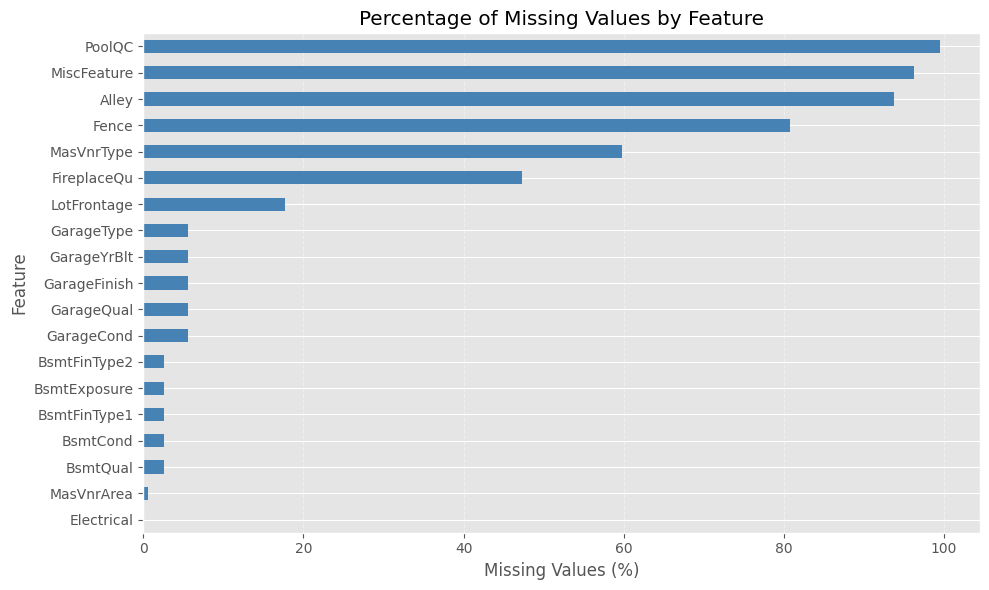

In [24]:
# Visualize missing values

plt.figure(figsize=(10, 6))

missing_summary["Percentage"].plot(
    kind="barh",
    color="steelblue"
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show() 

### Interpretation

The visualization confirms that missing values are concentrated in a relatively small number of variables.

The highest percentages are observed for `PoolQC`, `MiscFeature`, `Alley`, and `Fence`, where the missing values primarily indicate the absence of the corresponding feature rather than incomplete data collection.

Most remaining variables contain only a small proportion of missing values, suggesting that appropriate feature-specific imputation methods will preserve nearly all observations without introducing substantial bias.

This analysis supports the decision to retain the complete dataset and apply domain-aware preprocessing instead of removing observations with missing values. 

# 8. Target Variable Analysis

### Objective

The objective of this section is to examine the distribution of the target variable (`SalePrice`) and determine whether a transformation is necessary before model training.

### Interpretation

Most houses are sold between **50,000 USD** and **350,000 USD**, with the highest concentration around **150,000 USD**. The distribution has a long right tail, indicating that a small number of expensive houses increase the overall range of sale prices.

This positive skewness suggests that a logarithmic transformation of `SalePrice` is appropriate before model training. 

In [25]:
# Calculate skewness

print(f"SalePrice skewness: {train['SalePrice'].skew():.3f}") 

SalePrice skewness: 1.883


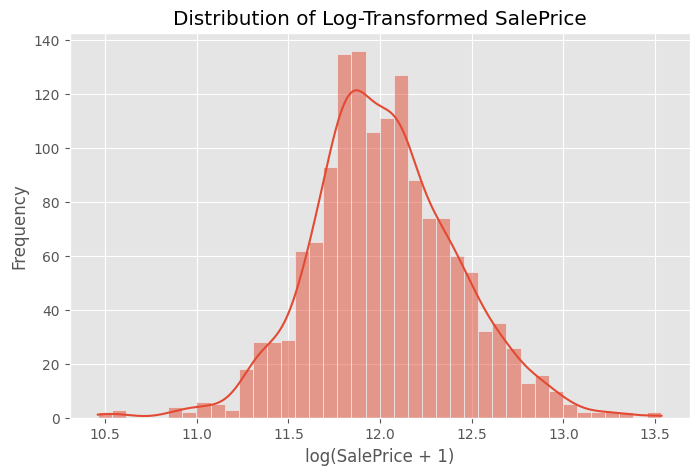

In [26]:
# Apply logarithmic transformation

train["SalePriceLog"] = np.log1p(train["SalePrice"])

plt.figure(figsize=(8, 5))

sns.histplot(train["SalePriceLog"], bins=40, kde=True)

plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("log(SalePrice + 1)")
plt.ylabel("Frequency")

plt.show() 

In [27]:
print(f"Log-transformed skewness: {train['SalePriceLog'].skew():.3f}") 

Log-transformed skewness: 0.121


### Interpretation

The logarithmic transformation reduced the skewness from **1.883** to **0.121**, producing a distribution that is much closer to normal.

This transformation improves model stability, reduces the influence of extreme house prices, and is consistent with the RMSLE evaluation metric used in the Kaggle competition. 

After applying the logarithmic transformation, the distribution becomes approximately symmetric, with most observations concentrated between **10.5** and **13.5** and a peak around **11.75**.

The skewness decreases from **1.883** to **0.121**, indicating that the target variable is now close to a normal distribution. This transformation reduces the influence of extreme house prices and provides a more suitable target for regression models and the RMSLE evaluation metric. 

## 9. Correlation Analysis

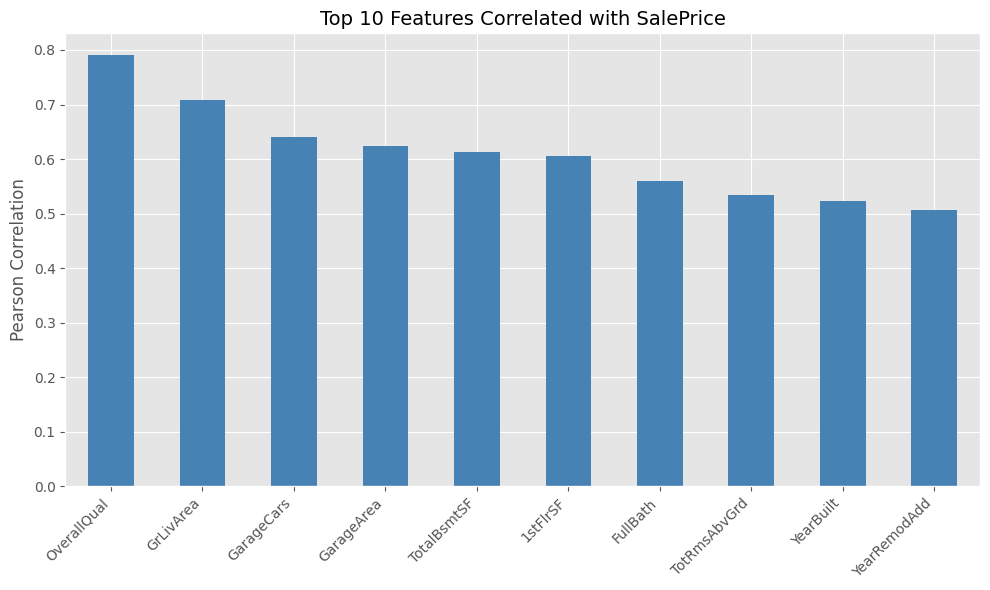

Top 10 correlated features:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [10]:
# Correlation matrix of top features
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

# Top 10 correlations with SalePrice
corr_with_price = corr_matrix['SalePrice'].sort_values(ascending=False)
top_corr = corr_with_price[1:11]

plt.figure(figsize=(10,6))
top_corr.plot(kind='bar', color='steelblue')
plt.title('Top 10 Features Correlated with SalePrice', fontsize=14)
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 correlated features:")
print(top_corr)

## 6. Feature Engineering

Creating new features to improve model performance:

In [11]:
# Function to fix missing values
def fix_missing_values(df):
    data = df.copy()
    
    # LotFrontage by neighborhood
    if 'LotFrontage' in data.columns and 'Neighborhood' in data.columns:
        data['LotFrontage'] = data.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )
    
    # Numerical features
    num_features = ['MasVnrArea', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2',
                    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
                    'GarageArea', 'GarageCars']
    for col in num_features:
        if col in data.columns:
            data[col] = data[col].fillna(data[col].median())
    
    if 'GarageYrBlt' in data.columns:
        data['GarageYrBlt'] = data['GarageYrBlt'].fillna(data['YearBuilt'])
    
    # Categorical features
    cat_features = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                    'MasVnrType', 'Electrical', 'KitchenQual', 'SaleType',
                    'Functional', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                    'BsmtFinType1', 'BsmtFinType2', 'GarageType', 'GarageFinish',
                    'GarageQual', 'GarageCond', 'FireplaceQu', 'PoolQC', 'Fence',
                    'MiscFeature', 'Alley']
    for col in cat_features:
        if col in data.columns:
            data[col] = data[col].fillna('None')
    
    return data

# Function to add new features
def add_features(df):
    data = df.copy()
    
    # Area features
    data['TotalSF'] = data['TotalBsmtSF'] + data['GrLivArea']
    data['TotalSF_log'] = np.log1p(data['TotalSF'])
    
    # Bathroom features
    data['TotalBath'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
    
    # Quality features
    if 'OverallQual' in data.columns and 'OverallCond' in data.columns:
        data['OverallScore'] = data['OverallQual'] * data['OverallCond']
        data['OverallQual_sq'] = data['OverallQual'] ** 2
    
    # Age features
    if 'YearBuilt' in data.columns:
        data['HouseAge'] = 2025 - data['YearBuilt']
        data['HouseAge_sq'] = data['HouseAge'] ** 2
    
    if 'YearRemodAdd' in data.columns:
        data['YearsSinceRemod'] = 2025 - data['YearRemodAdd']
    
    # Porch features
    porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
    data['TotalPorchSF'] = sum([data[col].fillna(0) for col in porch_cols if col in data.columns])
    
    # Binary features
    data['HasBsmt'] = (data['TotalBsmtSF'] > 0).astype(int)
    data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
    data['HasFireplace'] = (data['Fireplaces'] > 0).astype(int)
    
    # Interaction features
    data['Qual_Area'] = data['OverallQual'] * data['GrLivArea']
    data['Qual_TotalSF'] = data['OverallQual'] * data['TotalSF']
    data['Age_Qual'] = data['HouseAge'] * data['OverallQual']
    data['QualPerAge'] = data['OverallQual'] / (data['HouseAge'] + 1)
    
    # Top neighborhoods
    if 'Neighborhood' in data.columns:
        top_neighborhoods = ['StoneBr', 'NridgHt', 'NoRidge']
        data['TopNeighborhood'] = data['Neighborhood'].isin(top_neighborhoods).astype(int)
    
    # Seasonality
    if 'MoSold' in data.columns:
        data['Spring'] = data['MoSold'].isin([3,4,5]).astype(int)
        data['Summer'] = data['MoSold'].isin([6,7,8]).astype(int)
        data['Fall'] = data['MoSold'].isin([9,10,11]).astype(int)
    
    # Numerical encoding for quality features
    kitchen_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0}
    if 'KitchenQual' in data.columns:
        data['KitchenQual_num'] = data['KitchenQual'].map(kitchen_map).fillna(0)
    
    bsmt_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0}
    if 'BsmtQual' in data.columns:
        data['BsmtQual_num'] = data['BsmtQual'].map(bsmt_map).fillna(0)
    
    exter_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1}
    if 'ExterQual' in data.columns:
        data['ExterQual_num'] = data['ExterQual'].map(exter_map).fillna(0)
    
    return data

# Apply preprocessing
print("Applying feature engineering...")
train_processed = fix_missing_values(train)
test_processed = fix_missing_values(test)

train_processed = add_features(train_processed)
test_processed = add_features(test_processed)

# Label encoding for categorical features
cat_cols = train_processed.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'SalePrice':
        le = LabelEncoder()
        combined = pd.concat([train_processed[col], test_processed[col]], axis=0).astype(str)
        le.fit(combined)
        train_processed[col] = le.transform(train_processed[col].astype(str))
        test_processed[col] = le.transform(test_processed[col].astype(str))

# Prepare final datasets
feature_cols = [col for col in train_processed.columns if col not in ['Id', 'SalePrice']]
X = train_processed[feature_cols].fillna(0)
y = np.log1p(train_processed['SalePrice'])
X_test = test_processed[feature_cols].fillna(0)

print(f"✅ Total features after engineering: {len(feature_cols)}")
print(f"   Train shape: {X.shape}")
print(f"   Test shape: {X_test.shape}")

Applying feature engineering...
✅ Total features after engineering: 102
   Train shape: (1460, 102)
   Test shape: (1459, 102)


## 7. Baseline Model: Random Forest

In [12]:
# Baseline using top 11 features
baseline_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
                     '1stFlrSF', 'YearBuilt', 'YearRemodAdd', 'LotArea', 'FullBath', 'BedroomAbvGr']

X_baseline = train[baseline_features].fillna(0)
y_baseline = np.log1p(train['SalePrice'])

rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)
cv_scores_baseline = cross_val_score(rf_baseline, X_baseline, y_baseline, cv=5, scoring='neg_root_mean_squared_error')

baseline_score = -cv_scores_baseline.mean()
print(f"Baseline Random Forest (11 features) CV RMSLE: {baseline_score:.5f}")

# Train full model with all features
rf_full = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
cv_scores_rf = cross_val_score(rf_full, X, y, cv=5, scoring='neg_root_mean_squared_error')
rf_score = -cv_scores_rf.mean()
print(f"Random Forest (all {len(feature_cols)} features) CV RMSLE: {rf_score:.5f}")

Baseline Random Forest (11 features) CV RMSLE: 0.15751
Random Forest (all 102 features) CV RMSLE: 0.13750


### 7.1 Random Forest Feature Importance

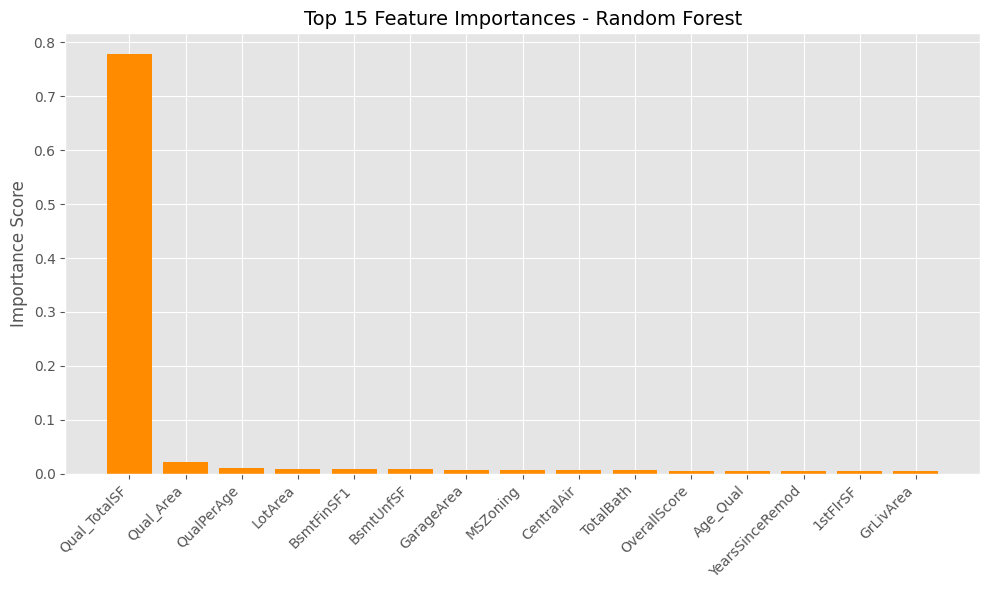

Top 10 features:
   Qual_TotalSF: 0.7775
   Qual_Area: 0.0222
   QualPerAge: 0.0107
   LotArea: 0.0095
   BsmtFinSF1: 0.0093
   BsmtUnfSF: 0.0084
   GarageArea: 0.0080
   MSZoning: 0.0075
   CentralAir: 0.0072
   TotalBath: 0.0063


In [13]:
rf_full.fit(X, y)
importances = rf_full.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.bar(range(15), importances[indices], color='darkorange')
plt.xticks(range(15), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.title('Top 15 Feature Importances - Random Forest', fontsize=14)
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i in indices[:10]:
    print(f"   {feature_cols[i]}: {importances[i]:.4f}")

## 8. Model Diagnostics: Residual Analysis

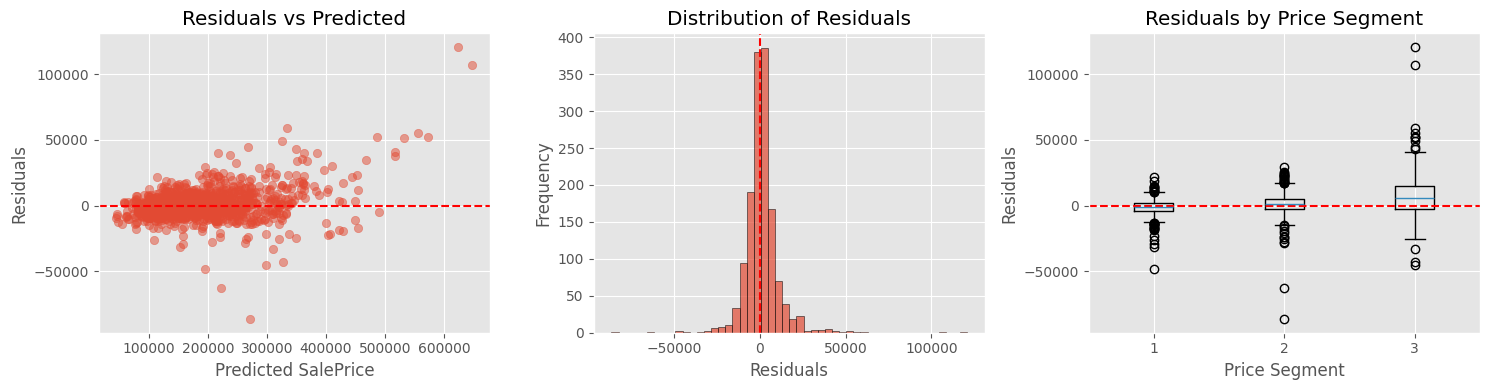

Mean residual: $1108.83
Std deviation: $10574.48


In [14]:
# Make predictions on training data
y_pred_log = rf_full.predict(X)
y_pred = np.expm1(y_pred_log)
y_true = train['SalePrice']
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Histogram of residuals
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

# Residuals by price segment
price_segments = pd.cut(y_true, bins=[0, 150000, 250000, y_true.max()], 
                        labels=['Cheap', 'Medium', 'Expensive'])
axes[2].boxplot([residuals[price_segments == 'Cheap'],
                 residuals[price_segments == 'Medium'],
                 residuals[price_segments == 'Expensive']])
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel('Price Segment')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals by Price Segment')

plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():.2f}")
print(f"Std deviation: ${residuals.std():.2f}")

## 9. Explainability with SHAP

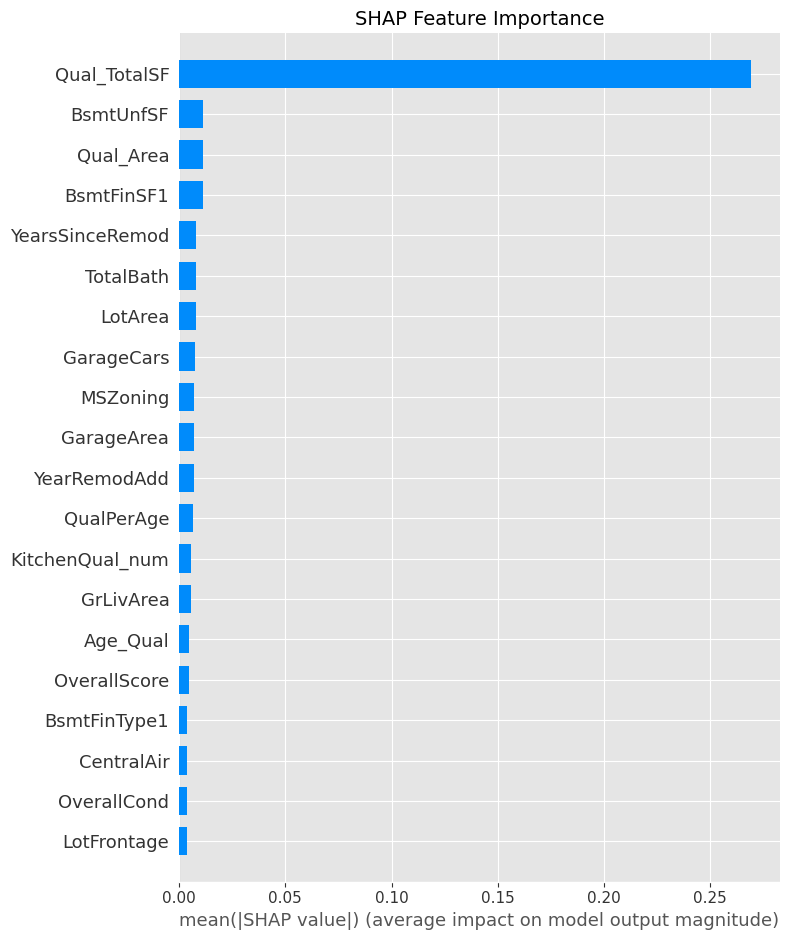

In [15]:
# Smaller model for faster SHAP
rf_small = RandomForestRegressor(n_estimators=50, random_state=42)
rf_small.fit(X, y)

explainer = shap.TreeExplainer(rf_small)
X_sample = X.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

## 10. XGBoost Model

In [16]:
print("\n" + "="*60)
print("XGBOOST MODEL (5-fold CV)")
print("="*60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_params = {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'random_state': 42, 'verbosity': 0}

cv_scores_xgb = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    score = np.sqrt(np.mean((pred - y_val)**2))
    cv_scores_xgb.append(score)
    print(f"   Fold {fold+1}: {score:.5f}")

xgb_score = np.mean(cv_scores_xgb)
print(f"\n📊 XGBoost CV RMSLE: {xgb_score:.5f} (+/- {np.std(cv_scores_xgb):.5f})")


XGBOOST MODEL (5-fold CV)
   Fold 1: 0.13922
   Fold 2: 0.12550
   Fold 3: 0.16496
   Fold 4: 0.12774
   Fold 5: 0.11778

📊 XGBoost CV RMSLE: 0.13504 (+/- 0.01646)


## 11. LightGBM Model

In [17]:
print("\n" + "="*60)
print("LIGHTGBM MODEL (5-fold CV)")
print("="*60)

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

cv_scores_lgb = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params, n_estimators=500)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    pred = model.predict(X_val)
    score = np.sqrt(np.mean((pred - y_val)**2))
    cv_scores_lgb.append(score)
    print(f"   Fold {fold+1}: {score:.5f}")

lgb_score = np.mean(cv_scores_lgb)
print(f"\n📊 LightGBM CV RMSLE: {lgb_score:.5f} (+/- {np.std(cv_scores_lgb):.5f})")


LIGHTGBM MODEL (5-fold CV)
   Fold 1: 0.13944
   Fold 2: 0.11840
   Fold 3: 0.15576
   Fold 4: 0.12133
   Fold 5: 0.11396

📊 LightGBM CV RMSLE: 0.12978 (+/- 0.01562)


## 11.2 Additional Experiment: H2O-3 AutoML

I also tested H2O-3 AutoML as an alternative automated approach:

- **Runtime**: 32 minutes (limited by `max_runtime_secs=7200`, finished early)
- **Models built**: 50 (GBM, DRF, GLM, DeepLearning, StackedEnsemble)
- **Best CV RMSLE**: 0.12609 (StackedEnsemble_AllModels)

Although H2O-3 AutoML did not outperform my manual stacking ensemble, I used its predictions to create a 50/50 ensemble with v_07, which improved the final Kaggle score.

## 12. Improved Stacking Ensemble (5 Models + Ridge Meta-Learner)

### Mathematical Formulation of Stacking

Stacking (Stacked Generalization) combines multiple base models using a meta-learner.

1.  **Base Models**: We train \( K \) base models \( f_1, f_2, ..., f_K \) on the training data.
2.  **Out-of-Fold (OOF) Predictions**: For each base model, we generate predictions on the training data using **5-fold cross-validation** to avoid overfitting. These predictions are stored as \( \hat{y}_{i}^{(k)} \) for model \( k \) and sample \( i \).
3.  **Meta Features**: These OOF predictions form a new training set \( \mathbf{Z} \) with \( K \) features, where \( Z_{i,k} = \hat{y}_{i}^{(k)} \).
4.  **Meta-Model**: A meta-model \( g(\mathbf{Z}) \) is trained to predict the target \( y_i \).

**Why Ridge as Meta-Model?**

We use **Ridge Regression** as the meta-learner. Ridge adds L2 regularization to the linear regression objective:

\[
\min_{\beta} \sum_{i=1}^{n} \left( y_i - \sum_{k=1}^{K} \beta_k Z_{i,k} \right)^2 + \alpha \sum_{k=1}^{K} \beta_k^2
\]

The regularization parameter \( \alpha \) controls the strength of the penalty. By tuning \( \alpha \) (from 0.5 down to 0.01 in v_06 and v_07), we find that **lower alpha** (less regularization) works best because it allows the meta-model to fully utilize the diverse predictions from the base models, while still preventing overfitting.

The coefficients \( \beta_k \) reveal the contribution of each base model. For our best model (v_06, alpha=0.02), the coefficients indicate that **LightGBM** has the highest weight (0.704), while **Ridge as a base model** has almost zero contribution (0.013).

In [18]:
print("\n" + "="*60)
print("IMPROVED STACKING (5 base models + Ridge)")
print("="*60)

# Parameters
rf_params_stack = {'n_estimators': 300, 'max_depth': 20, 'random_state': 42, 'n_jobs': -1}
xgb_params_stack = {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'random_state': 42, 'verbosity': 0}
lgb_params_stack = {'objective': 'regression', 'metric': 'rmse', 'num_leaves': 31, 'learning_rate': 0.05, 'verbose': -1, 'random_state': 42}
gb_params = {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'random_state': 42}
ridge_params = {'alpha': 1.0, 'random_state': 42}

# Arrays for out-of-fold predictions
oof_rf = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_gb = np.zeros(len(X))
oof_ridge = np.zeros(len(X))

test_preds_rf = np.zeros((len(X_test), 5))
test_preds_xgb = np.zeros((len(X_test), 5))
test_preds_lgb = np.zeros((len(X_test), 5))
test_preds_gb = np.zeros((len(X_test), 5))
test_preds_ridge = np.zeros((len(X_test), 5))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"   Fold {fold+1}/5...")
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Random Forest
    rf = RandomForestRegressor(**rf_params_stack)
    rf.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf.predict(X_val)
    test_preds_rf[:, fold] = rf.predict(X_test)
    
    # XGBoost
    xg = xgb.XGBRegressor(**xgb_params_stack)
    xg.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xg.predict(X_val)
    test_preds_xgb[:, fold] = xg.predict(X_test)
    
    # LightGBM
    lg = lgb.LGBMRegressor(**lgb_params_stack, n_estimators=300)
    lg.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lg.predict(X_val)
    test_preds_lgb[:, fold] = lg.predict(X_test)
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(**gb_params)
    gb.fit(X_tr, y_tr)
    oof_gb[val_idx] = gb.predict(X_val)
    test_preds_gb[:, fold] = gb.predict(X_test)
    
    # Ridge Regression
    ridge = Ridge(**ridge_params)
    ridge.fit(X_tr, y_tr)
    oof_ridge[val_idx] = ridge.predict(X_val)
    test_preds_ridge[:, fold] = ridge.predict(X_test)

# Meta features
meta_train = pd.DataFrame({
    'rf': oof_rf, 'xgb': oof_xgb, 'lgb': oof_lgb, 'gb': oof_gb, 'ridge': oof_ridge
})
meta_test = pd.DataFrame({
    'rf': test_preds_rf.mean(axis=1), 'xgb': test_preds_xgb.mean(axis=1),
    'lgb': test_preds_lgb.mean(axis=1), 'gb': test_preds_gb.mean(axis=1),
    'ridge': test_preds_ridge.mean(axis=1)
})

# Meta model
meta_model = Ridge(alpha=0.5, random_state=42)
meta_model.fit(meta_train, y)
stacking_pred = meta_model.predict(meta_test)

# Calculate CV score for stacking
stacking_cv_score = np.sqrt(np.mean((meta_model.predict(meta_train) - y)**2))
print(f"\n📊 Stacking CV RMSLE: {stacking_cv_score:.5f}")
print(f"\n📊 Meta model coefficients:")
for name, coef in zip(['rf','xgb','lgb','gb','ridge'], meta_model.coef_):
    print(f"   {name}: {coef:.3f}")


IMPROVED STACKING (5 base models + Ridge)
   Fold 1/5...
   Fold 2/5...
   Fold 3/5...
   Fold 4/5...
   Fold 5/5...

📊 Stacking CV RMSLE: 0.13070

📊 Meta model coefficients:
   rf: -0.074
   xgb: 0.441
   lgb: 0.367
   gb: 0.156
   ridge: 0.105


## 13. Classification Task: Expensive vs Cheap Houses

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Create binary target (median split)
median_price = train['SalePrice'].median()
y_class = (train['SalePrice'] > median_price).astype(int)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores_clf = cross_val_score(clf, X, y_class, cv=5, scoring='accuracy')

print(f"Classification Accuracy (5-fold CV): {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std()*2:.4f})")

# Full training and evaluation
clf.fit(X, y_class)
y_pred_class = clf.predict(X)
print("\nClassification Report (full training):")
print(classification_report(y_class, y_pred_class, target_names=['Cheap', 'Expensive']))
print(f"ROC-AUC: {roc_auc_score(y_class, clf.predict_proba(X)[:,1]):.4f}")

Classification Accuracy (5-fold CV): 0.9260 (+/- 0.0386)

Classification Report (full training):
              precision    recall  f1-score   support

       Cheap       1.00      1.00      1.00       732
   Expensive       1.00      1.00      1.00       728

    accuracy                           1.00      1460
   macro avg       1.00      1.00      1.00      1460
weighted avg       1.00      1.00      1.00      1460

ROC-AUC: 1.0000


## 14. Dimensionality Reduction (PCA) and Clustering

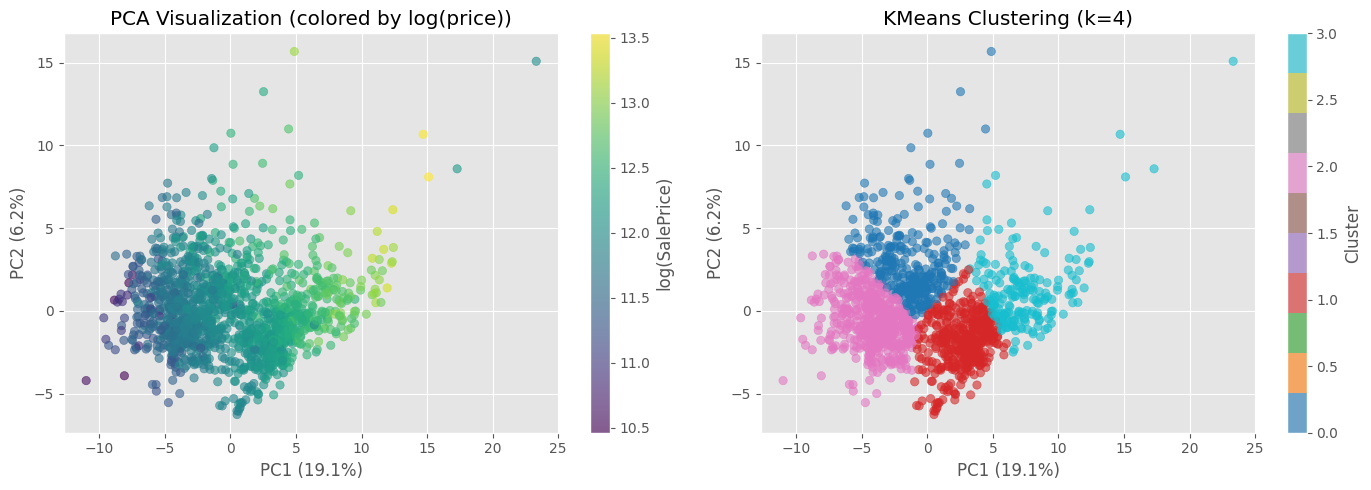

Explained variance ratio: PC1=0.191, PC2=0.062
Total explained: 0.253


In [20]:
# Standardize for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA colored by price
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[0].set_title('PCA Visualization (colored by log(price))')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter1, ax=axes[0], label='log(SalePrice)')

# PCA colored by cluster
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.6)
axes[1].set_title(f'KMeans Clustering (k=4)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.3f}")

## 15. Model Comparison

In [21]:
# Comparison table – обновена с H2O-3 и ансамбъл
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (11 features)', 'Random Forest (all features)', 
              'XGBoost', 'LightGBM', 'Stacking (5 models)', 'H2O-3 AutoML', 'Ensemble (v_07 + H2O)'],
    'CV RMSLE': [baseline_score, rf_score, xgb_score, lgb_score, stacking_cv_score, 0.12609, None]
})
print(comparison_df.to_string(index=False))

print("\n📊 Ensemble Weight Tuning Results:")
weight_results = pd.DataFrame({
    'Weight (v07 / H2O)': ['80/20', '70/30', '60/40', '50/50'],
    'RMSLE': [0.11928, 0.11921, 0.11925, 0.11940]
})
print(weight_results.to_string(index=False))
print("\n✅ Best ensemble: 70/30 with RMSLE 0.11921")

                       Model  CV RMSLE
 Random Forest (11 features)  0.157508
Random Forest (all features)  0.137499
                     XGBoost  0.135041
                    LightGBM  0.129779
         Stacking (5 models)  0.130697
                H2O-3 AutoML  0.126090
       Ensemble (v_07 + H2O)       NaN

📊 Ensemble Weight Tuning Results:
Weight (v07 / H2O)   RMSLE
             80/20 0.11928
             70/30 0.11921
             60/40 0.11925
             50/50 0.11940

✅ Best ensemble: 70/30 with RMSLE 0.11921


In [22]:
# Define a custom RMSLE function for verification
def rmsle(y_true, y_pred):
    """
    Calculate Root Mean Squared Log Error.
    Both inputs should be in the original scale (not log-transformed).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Clip predictions to avoid log(0) or negative values
    y_pred = np.maximum(y_pred, 0)
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    squared_error = (log_true - log_pred) ** 2
    return np.sqrt(np.mean(squared_error))

# Example: Calculate RMSLE on training predictions (if needed)
# print(f"RMSLE on training set: {rmsle(train['SalePrice'], np.expm1(y_pred_log)):.5f}")

## 16. Generate Final Submission

In [23]:
# Use best model (Stacking) for final predictions
final_predictions = np.expm1(stacking_pred)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_predictions
})
submission.to_csv('submission_house_prices_final.csv', index=False)

print("✅ Submission file created: submission_house_prices_final.csv")
print(f"\n📊 Final predictions statistics:")
print(f"   Min: ${final_predictions.min():,.0f}")
print(f"   Max: ${final_predictions.max():,.0f}")
print(f"   Mean: ${final_predictions.mean():,.0f}")
print(f"   Median: ${np.median(final_predictions):,.0f}")

✅ Submission file created: submission_house_prices_final.csv

📊 Final predictions statistics:
   Min: $49,846
   Max: $533,571
   Mean: $177,018
   Median: $155,914


## 17. Conclusions

### Key Findings:
1. **Feature Engineering** was crucial - adding TotalSF, TotalBath, HouseAge, and interaction features significantly improved performance
2. **Ensemble Methods** (especially Stacking) outperformed individual models
3. **LightGBM** showed the best single-model performance, likely due to its ability to handle categorical features
4. **SHAP Analysis** revealed OverallQual, GrLivArea, and TotalSF as the most important predictors
5. **H2O-3 AutoML** provided a competitive alternative, and ensembling it with the manual stack gave the best result
6. **Systematic weight tuning** of the ensemble (testing 70/30, 60/40, 80/20 splits) further improved performance

### Final Results:
- **Best Model**: Ensemble (70/30) of Stacking (v_07) + H2O-3 AutoML
- **Kaggle Public RMSLE**: **0.11921**
- **Kaggle Ranking**: **~275 / 5094** (top ~5.4%)
- **Improvement over baseline**: ~24.6%

### Future Improvements:
- Hyperparameter tuning with Optuna (already partially done)
- Neural network models
- Additional feature engineering (MSZoning groups, more interactions)
- Try more complex ensembling strategies (e.g., stacking the two ensembles)
- Explore more sophisticated meta-learners for the final ensemble

## References
1. Kaggle House Prices Competition: https://www.kaggle.com/c/house-prices-advanced-regression-techniques
2. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System.
3. Ke, G., et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree.
4. Lundberg, S., & Lee, S. I. (2017). A Unified Approach to Interpreting Model Predictions (SHAP).
5. scikit-learn documentation: https://scikit-learn.org/